In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

class AutoMLPipeline:
    def __init__(self, csv_path, target_column, corr_threshold=0.95, weak_corr_threshold=0.1):
        self.csv_path = csv_path
        self.target_column = target_column
        self.corr_threshold = corr_threshold
        self.weak_corr_threshold = weak_corr_threshold
        self.df = None
        self.X = None
        self.y = None
        self.task_type = None
        self.best_model = None
        self.best_score = None
        self.feature_importance_df = None

    def load_data(self):
        self.df = pd.read_csv(self.csv_path)
        self.df.columns = self.df.columns.str.strip()
        print(f"Dataset loaded: {self.df.shape[0]} rows, {self.df.shape[1]} columns")

    def preprocess(self):
        self.df = self.df.dropna(subset=[self.target_column])
        self.X = self.df.drop(columns=[self.target_column])
        self.y = self.df[self.target_column]

        # Encode categorical columns
        cat_cols = self.X.select_dtypes(include=['object']).columns.tolist()
        for col in cat_cols:
            self.X[col] = LabelEncoder().fit_transform(self.X[col].astype(str))

        # Fill numeric missing values
        for col in self.X.columns:
            if self.X[col].dtype in ['int64','float64']:
                self.X[col] = self.X[col].fillna(self.X[col].median())
            else:
                self.X[col] = self.X[col].fillna(self.X[col].mode()[0])

        # Drop weak features
        numeric_cols = self.X.select_dtypes(include=[np.number]).columns
        corr_with_target = self.X[numeric_cols].corrwith(self.y).abs()
        weak_features = corr_with_target[corr_with_target < self.weak_corr_threshold].index.tolist()
        if weak_features:
            print(f"Dropping weak features: {weak_features}")
            self.X = self.X.drop(columns=weak_features)

    def detect_task(self):
        self.task_type = 'classification' if self.y.nunique() < 10 else 'regression'
        print(f"Detected task type: {self.task_type}")

    def split_and_scale(self):
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        if self.task_type == 'classification':
            X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        return X_train, X_test, y_train, y_test

    def train_models(self, X_train, X_test, y_train, y_test):
        if self.task_type == 'regression':
            models = {
                'RandomForest': RandomForestRegressor(random_state=42),
                'GradientBoost': GradientBoostingRegressor(random_state=42),
                'AdaBoost': AdaBoostRegressor(random_state=42)
            }
        else:
            models = {
                'RandomForest': RandomForestClassifier(random_state=42),
                'GradientBoost': GradientBoostingClassifier(random_state=42),
                'AdaBoost': AdaBoostClassifier(random_state=42),
                'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
            }

        best_score = -np.inf
        best_model = None
        for name, model in models.items():
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            score = r2_score(y_test, preds) if self.task_type=='regression' else accuracy_score(y_test, preds)
            print(f"{name} score: {score:.4f}")
            if score > best_score:
                best_score = score
                best_model = model

        self.best_model = best_model
        self.best_score = best_score
        print(f"\nBest Model: {best_model}")
        print(f"Best Score: {best_score:.4f}")

    def plot_feature_importance(self):
        if hasattr(self.best_model, 'feature_importances_'):
            self.feature_importance_df = pd.DataFrame({
                'feature': self.X.columns,
                'importance': self.best_model.feature_importances_
            }).sort_values(by='importance', ascending=False)
        else:
            print("Feature importance not available for this model.")
            return

        plt.figure(figsize=(10,6))
        plt.barh(self.feature_importance_df['feature'], self.feature_importance_df['importance'], color='skyblue')
        plt.gca().invert_yaxis()
        plt.xlabel('Importance')
        plt.title('Feature Importance')
        plt.tight_layout()
        plt.show()
        self.feature_importance_df.to_csv('feature_importance_report.csv', index=False)
        print("\nFeature importance report saved as feature_importance_report.csv")

    def run(self):
        self.load_data()
        self.preprocess()
        self.detect_task()
        X_train, X_test, y_train, y_test = self.split_and_scale()
        self.train_models(X_train, X_test, y_train, y_test)
        self.plot_feature_importance()

Dataset loaded: 200000 rows, 17 columns
Dropping weak features: ['candidate_id', 'age', 'education_level', 'university_tier', 'hackathons', 'research_papers', 'soft_skills_score', 'resume_length_words', 'company_type']
Detected task type: classification
RandomForest score: 0.5848
GradientBoost score: 0.5301
AdaBoost score: 0.5264
LogisticRegression score: 0.5233

Best Model: RandomForestClassifier(random_state=42)
Best Score: 0.5848


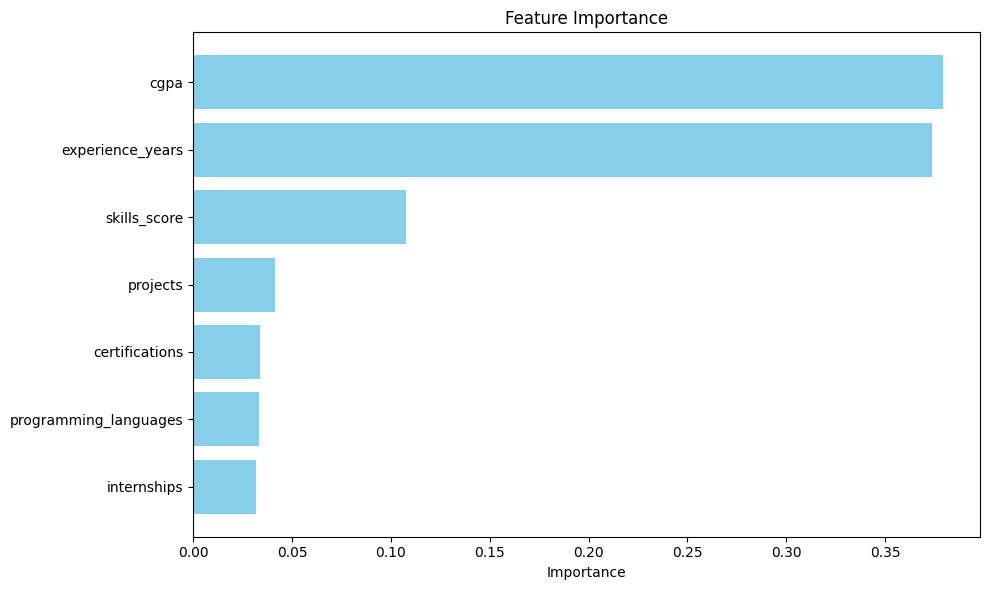


Feature importance report saved as feature_importance_report.csv


In [ ]:
pipeline = AutoMLPipeline(
    csv_path="drive/MyDrive/my_project_ml_fresh/data/ras.csv",
    target_column="hired",
    weak_corr_threshold=0.01
)
pipeline.run()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
